In [1]:
import tensorflow as tf
import numpy as np
import os
import sys
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, ReLU, Add, AveragePooling2D, Lambda, BatchNormalization, Conv1D, MaxPooling1D
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop, Adam
from keras import backend as K
from scipy.fftpack import fft
from scipy import signal
import h5py
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from numpy import sum, sqrt
from numpy.random import standard_normal, uniform
sys.path.append('.')

In [2]:
def load_iq_files(path, num_files=1235):
    I_data = []
    Q_data = []
    min_length = float('inf')

    # Determine the minimum length of data across all files
    for i in range(1, num_files + 1):
        I_file = os.path.join(path, f'I{i}.txt')
        Q_file = os.path.join(path, f'Q{i}.txt')
        I_length = len(np.loadtxt(I_file))
        Q_length = len(np.loadtxt(Q_file))
        if I_length < min_length:
            min_length = I_length
        if Q_length < min_length:
            min_length = Q_length

    # Load and trim data to the minimum length
    for i in range(1, num_files + 1):
        I_file = os.path.join(path, f'I{i}.txt')
        Q_file = os.path.join(path, f'Q{i}.txt')
        I_data.append(np.loadtxt(I_file)[:min_length])
        Q_data.append(np.loadtxt(Q_file)[:min_length])

    return np.array(I_data), np.array(Q_data), min_length

# Channel-independent spectrogram class
class ChannelIndSpectrogram():
    def __init__(self):
        pass

    def _normalization(self, data):
        normalized_results = []
        for signal in data:
            # Min-max normalizasyonu
            min_val = np.min(signal)
            max_val = np.max(signal)
            normalized_result = (signal - min_val) / (max_val - min_val)
            normalized_results.append(normalized_result)
        return np.array(normalized_results)

    def _spec_crop(self, x):
        '''Crop the generated channel-independent spectrogram.'''
        num_row = x.shape[0]
        x_cropped = x[round(num_row * 0.3):round(num_row * 0.7)]
        return x_cropped

    def _gen_single_channel_ind_spectrogram(self, sig, win_len=256, overlap=128):
        '''Convert IQ samples to channel-independent spectrogram according to specified window and overlap length.'''
        f, t, spec = signal.stft(sig, window='boxcar', nperseg=win_len, noverlap=overlap, nfft=win_len, return_onesided=False, padded=False, boundary=None)
        spec = np.fft.fftshift(spec, axes=0)
        chan_ind_spec = spec[:, 1:] / spec[:, :-1]
        chan_ind_spec_amp = np.log10(np.abs(chan_ind_spec) ** 2)
        return chan_ind_spec_amp

    def channel_ind_spectrogram(self, data):
        '''Convert IQ samples to channel-independent spectrograms.'''
        data = self._normalization(data)
        num_sample = data.shape[0]
        num_row = int(256 * 0.4)
        num_column = int(np.floor((data.shape[1] - 256) / 128 + 1) - 1)
        data_channel_ind_spec = np.zeros([num_sample, num_row, num_column, 1])

        for i in range(num_sample):
            chan_ind_spec_amp = self._gen_single_channel_ind_spectrogram(data[i])
            chan_ind_spec_amp = self._spec_crop(chan_ind_spec_amp)
            data_channel_ind_spec[i, :, :, 0] = chan_ind_spec_amp

        return data_channel_ind_spec

# Merge and prepare data and labels
def prepare_data(paths, num_files=1235):
    all_I_data = []
    all_Q_data = []
    labels = []
    min_lengths = []

    for i, (device, path) in enumerate(paths.items()):
        I_data, Q_data, min_length = load_iq_files(path, num_files=num_files)
        all_I_data.append(I_data)
        all_Q_data.append(Q_data)
        labels.append(np.full(I_data.shape[0], i))
        min_lengths.append(min_length)

    # Determine minimum length
    min_length = min(min_lengths)

    # Trim data to minimum length
    all_I_data = [data[:, :min_length] for data in all_I_data]
    all_Q_data = [data[:, :min_length] for data in all_Q_data]

    all_I_data = np.concatenate(all_I_data)
    all_Q_data = np.concatenate(all_Q_data)
    labels = np.concatenate(labels)

    return all_I_data, all_Q_data, labels

# Create complex IQ data
def create_complex_iq(I_data, Q_data):
    return I_data + 1j * Q_data

# Create and normalize spectrograms
def process_spectrograms(complex_data):
    cis = ChannelIndSpectrogram()
    data_channel_ind_spec = cis.channel_ind_spectrogram(complex_data)
    return data_channel_ind_spec

In [3]:
paths = {
    'Device_1': r'C:\new_data\device1',
    'Device_2': r'C:\new_data\device2',
    'Device_3': r'C:\new_data\device3',
    'Device_4': r'C:\new_data\device4'
}

all_I_data, all_Q_data, labels = prepare_data(paths, num_files=1235)
print(all_I_data.shape,all_Q_data.shape,labels.shape)

(4940, 38717) (4940, 38717) (4940,)


In [4]:
complex_data = create_complex_iq(all_I_data, all_Q_data)
print(complex_data.shape)

(4940, 38717)


In [12]:
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK  
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 
# #NOISE BURAYA EKLENECEK 


In [5]:
data_channel_ind_spec_normalized = process_spectrograms(complex_data)
print(data_channel_ind_spec_normalized.shape)
print(data_channel_ind_spec_normalized)

(4940, 102, 300, 1)
[[[[ 3.20692437e-01]
   [ 1.51463937e-01]
   [-2.47956110e-01]
   ...
   [ 1.30542847e-01]
   [-2.76793653e-01]
   [ 2.61349264e-01]]

  [[ 1.16262626e+00]
   [-2.16902210e-01]
   [-8.00113133e-02]
   ...
   [-1.37627241e-01]
   [ 7.44060226e-02]
   [ 2.42783306e-01]]

  [[ 1.09533510e+00]
   [ 2.44752808e-01]
   [-5.88354416e-02]
   ...
   [-1.98576499e-01]
   [-1.13691892e-01]
   [ 3.23995436e-01]]

  ...

  [[ 4.69251030e-01]
   [ 1.45274765e-02]
   [-5.72034474e-02]
   ...
   [ 5.98226991e-01]
   [-1.95886848e-01]
   [-3.84368055e-01]]

  [[ 2.27218723e-01]
   [ 9.57087346e-02]
   [ 1.87850387e-01]
   ...
   [ 7.22720530e-01]
   [-1.61126072e-01]
   [-9.84684228e-01]]

  [[ 7.61943821e-01]
   [-2.83459891e-01]
   [ 1.72259032e-01]
   ...
   [ 4.97918505e-01]
   [-3.12961255e-01]
   [-8.06757506e-02]]]


 [[[ 9.06460274e-01]
   [-2.77880329e-01]
   [-5.26116672e-01]
   ...
   [ 4.47894575e-02]
   [ 4.12353800e-02]
   [ 4.61185676e-01]]

  [[ 1.86564975e+00]
   [-

In [6]:
training_data = []

def create_training_data(Input_list, Desired_target_index):
    for i in range(len(Input_list)):  
     training_data.append([Input_list[i], Desired_target_index[i]])  

create_training_data(data_channel_ind_spec_normalized, labels)
print("The lenght training data list after adding sine data: ", len(training_data))

import random
random.shuffle(training_data)
x_train = []
y_train = []

for features, label in training_data:
    x_train.append(features)
    y_train.append(label)

x_train = np.array(x_train)
X_train = x_train 
y_train = np.uint8(y_train)

The lenght training data list after adding sine data:  4940


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3556, 102, 300, 1)
(988, 102, 300, 1)
(3556,)
(988,)


In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, BatchNormalization, ReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout

def create_model(input_shape, num_classes):
    model = tf.keras.Sequential()
    
    # İlk 1D Konvolüsyon Katmanı
    model.add(Conv1D(filters=4, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    # İkinci 1D Konvolüsyon Katmanı
    model.add(Conv1D(filters=8, kernel_size=6, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
   
    
    # Max-Pooling Katmanı
    model.add(MaxPooling1D(pool_size=2, strides=2))
    
    # Düzleştirme (Flattening)
    model.add(Flatten())
    
    # Tam Bağlantılı (Dense) Katman
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.5))
    
    # Çıkış Katmanı
    model.add(Dense(num_classes, activation='softmax'))  # Multi-class classification
    
    return model



num_classes = 4  # Sınıflandırılacak sınıf sayısı
input_shape = (102, 300)  # Girdi şekli

# Modeli oluştur
model = create_model(input_shape, num_classes)

# Optimizasyon algoritması ve parametreleri
optimizer = RMSprop(learning_rate=0.001)

# Erken Durdurma ve LR Azaltma Geri Bildirimleri
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1)

# Modeli derleme
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model özetini yazdırma
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 100, 4)            3604      
                                                                 
 batch_normalization (Batch  (None, 100, 4)            16        
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 100, 4)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 95, 8)             200       
                                                                 
 batch_normalization_1 (Bat  (None, 95, 8)             32        
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 95, 8)             0

In [9]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=32, callbacks=[early_stopping, reduce_lr])
from sklearn.metrics import f1_score

# Modeli değerlendirme
test_loss, test_accuracy = model.evaluate(X_test,y_test )

# Tahminler
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
f1 = f1_score(y_test, predicted_classes, average='macro')

# Eğitim ve doğrulama metriklerinin geçmişi
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Eğitim ve doğrulama doğrulukları
print("Eğitim Doğruluğu:", training_accuracy[-1])
print("Doğrulama Doğruluğu:", validation_accuracy[-1])

# Eğitim ve doğrulama kayıpları
print("Eğitim Kaybı:", training_loss[-1])
print("Doğrulama Kaybı:", validation_loss[-1])

# Test doğruluğu
print("Test Doğruluğu:", test_accuracy)

# F1 skoru
print("F1 Skoru:", f1)

Epoch 1/20
112/112 [==============================] - 3s 15ms/step - loss: 1.5757 - accuracy: 0.4078 - val_loss: 0.5412 - val_accuracy: 0.8157 - lr: 0.0010
Epoch 2/20
112/112 [==============================] - 1s 13ms/step - loss: 0.6944 - accuracy: 0.6597 - val_loss: 0.3354 - val_accuracy: 0.8232 - lr: 0.0010
Epoch 3/20
112/112 [==============================] - 1s 13ms/step - loss: 0.5014 - accuracy: 0.7261 - val_loss: 0.3234 - val_accuracy: 0.8409 - lr: 0.0010
Epoch 4/20
112/112 [==============================] - 2s 14ms/step - loss: 0.4323 - accuracy: 0.7461 - val_loss: 0.3038 - val_accuracy: 0.8889 - lr: 0.0010
Epoch 5/20
112/112 [==============================] - 1s 13ms/step - loss: 0.3673 - accuracy: 0.8043 - val_loss: 0.2179 - val_accuracy: 0.9167 - lr: 0.0010
Epoch 6/20
112/112 [==============================] - 1s 13ms/step - loss: 0.2642 - accuracy: 0.8737 - val_loss: 0.0748 - val_accuracy: 0.9773 - lr: 0.0010
Epoch 7/20
112/112 [==============================] - 1s 12ms/st

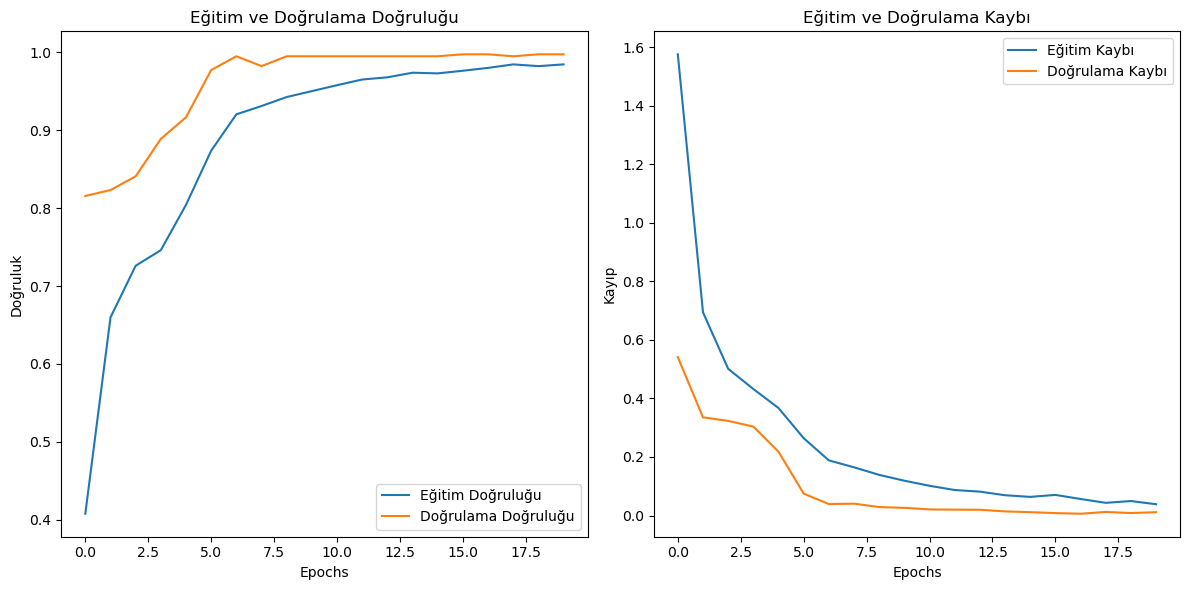

In [10]:
import matplotlib.pyplot as plt

# Eğitim ve doğrulama doğruluğunu çiz
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(training_accuracy, label='Eğitim Doğruluğu')
plt.plot(validation_accuracy, label='Doğrulama Doğruluğu')
plt.xlabel('Epochs')
plt.ylabel('Doğruluk')
plt.title('Eğitim ve Doğrulama Doğruluğu')
plt.legend()

# Eğitim ve doğrulama kaybını çiz
plt.subplot(1, 2, 2)
plt.plot(training_loss, label='Eğitim Kaybı')
plt.plot(validation_loss, label='Doğrulama Kaybı')
plt.xlabel('Epochs')
plt.ylabel('Kayıp')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.legend()

plt.tight_layout()
plt.show()

31/31 [==============================] - 0s 6ms/step
Confusion matrix, without normalization
[[246   0   1   3]
 [  0 248   0   2]
 [  0   0 241   0]
 [  0   1   0 246]]


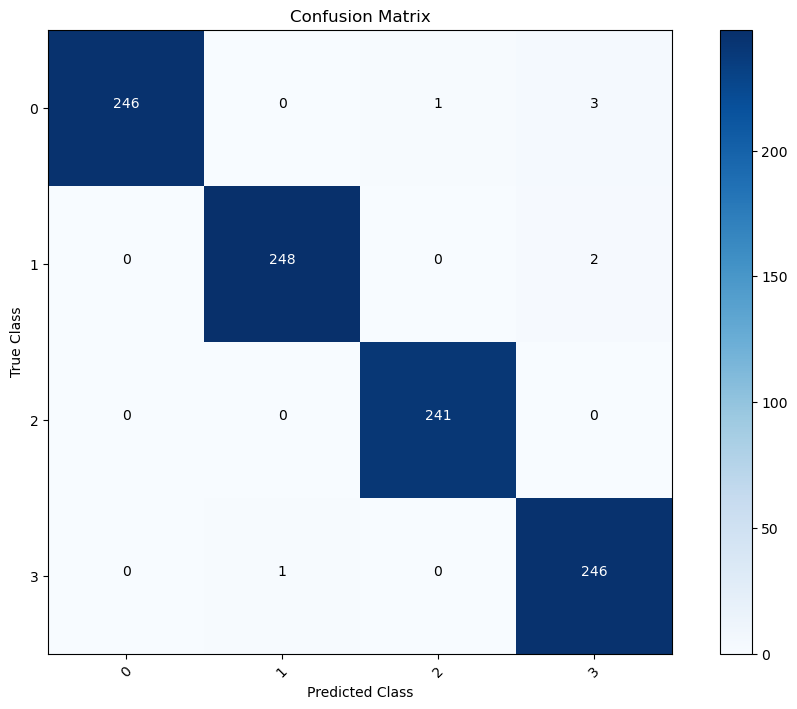

Accuracy of class 0 = 98.40%
Accuracy of class 1 = 99.20%
Accuracy of class 2 = 100.00%
Accuracy of class 3 = 99.60%


['98.40', '99.20', '100.00', '99.60']

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# Predict
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
#true_classes = np.argmax(y_test, axis=1)  # One-hot encoded'den sınıf etiketlerine dönüştürme

# Confusion matrix hesaplama
cm = confusion_matrix(y_test, predicted_classes)

# Confusion matrix'i görselleştirme
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    plt.figure(figsize=(10, 7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()

plot_confusion_matrix(cm, list(range(max(y_test)+1)))

def accuracy_of_each_class(confusion_matrix_output):
    size_of_confusion_matrix = len(confusion_matrix_output)
    accuracy_per_class = []
    for i in range(size_of_confusion_matrix):
        accuracy = (confusion_matrix_output[i][i] * 100) / sum(confusion_matrix_output[i])
        accuracy_per_class.append("{:.2f}".format(accuracy))
        print("Accuracy of class {} = {:.2f}%".format(i, accuracy))
    return accuracy_per_class

accuracy_of_each_class(cm)